<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week5_Day2_Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Comprendre les types de classification

a) Classification binaire

La classification binaire consiste à prédire une seule étiquette parmi deux classes possibles.

Exemples :

* Email → Spam ou Non-spam
* Transaction → Fraude ou Non-fraude
* Maladie → Présente ou Absente

Sortie du modèle :
Une probabilité comprise entre 0 et 1 avec une fonction d’activation Sigmoid.

⸻

b) Classification multi-classes

La classification multi-classes consiste à prédire une classe parmi plusieurs classes possibles, où chaque exemple appartient à une seule classe.

Exemples :

* Reconnaissance des chiffres de 0 à 9
* Classification des espèces de fleurs

Sortie du modèle :
Plusieurs probabilités avec une fonction d’activation Softmax.

⸻

c) Classification multi-label

La classification multi-label permet d’attribuer plusieurs étiquettes à une même donnée.

Exemples :
Une image peut contenir :

* Un chien
* Une personne
* Une voiture

Une même image peut donc avoir plusieurs labels simultanément.

Sortie du modèle :
Plusieurs sorties Sigmoid, une pour chaque label.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_circles

In [2]:
samples = 1000

X, y = make_circles(
    n_samples=samples,
    noise=0.03,
    random_state=42
)

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)

Forme de X : (1000, 2)
Forme de y : (1000,)


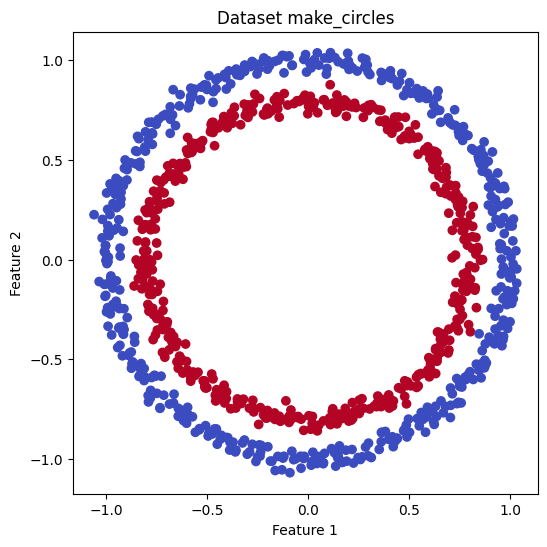

In [3]:
plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset make_circles")
plt.show()

Interprétation :

* Les points rouges représentent une classe.
* Les points bleus représentent l’autre classe.
* Le problème n’est pas linéaire car une simple ligne droite ne peut pas séparer les deux cercles.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(800, 2) (200, 2)


In [5]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

model_1.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer="SGD",
    metrics=["accuracy"]
)

history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=0
)

Observation :

Le modèle simple a généralement de faibles performances car il ne possède pas assez de couches pour apprendre une frontière de décision complexe.

In [6]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_2.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=200,
    verbose=0
)

In [7]:
model_2.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0185  


[0.018523115664720535, 1.0]

In [8]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    X_grid = np.c_[xx.ravel(), yy.ravel()]

    predictions = model.predict(X_grid, verbose=0)
    predictions = (predictions > 0.5).astype(int)

    predictions = predictions.reshape(xx.shape)

    plt.contourf(xx, yy, predictions, alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm")
    plt.show()

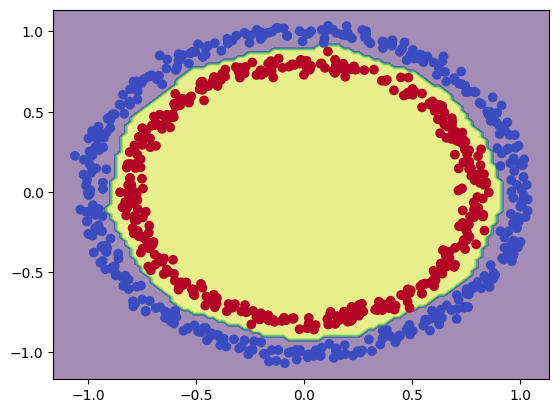

In [9]:
plot_decision_boundary(model_2, X_train, y_train)

In [10]:
activation="relu"

Caractéristiques :

* Évite en partie le problème du gradient qui disparaît.
* Apprentissage rapide.
* Très utilisée dans les couches cachées.

In [11]:
activation="sigmoid"

Caractéristiques :

* Produit une valeur entre 0 et 1.
* Très utile pour la classification binaire.
* Utilisée généralement dans la couche de sortie.

Résumé des principaux points à retenir

Durant ce défi, nous avons appris à :

* Comprendre les différences entre la classification binaire, multi-classes et multi-label.
* Générer un dataset artificiel avec make_circles.
* Visualiser la distribution des données avec matplotlib.
* Construire un réseau neuronal simple avec TensorFlow.
* Améliorer le modèle en ajoutant des couches cachées, des neurones et l’optimiseur Adam.
* Utiliser les fonctions d’activation ReLU et Sigmoid.
* Séparer les données en ensembles d’entraînement et de test.
* Évaluer un modèle avec la perte (loss) et l’exactitude (accuracy).
* Visualiser la frontière de décision afin de mieux comprendre comment le réseau sépare les classes.